# 10 - Transfer ResNet18 PyTorch v2

This notebook trains **Transfer ResNet18 v2** on the processed dataset:

`I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\`

## Goal
Keep the original **50-class task**, improve generalization with Dataset 2 overlap samples, and make training curves smoother and more interpretable.

## Changes from the previous ResNet18 version
- Keep **two-stage transfer learning**
- Reduce the abrupt jump between stages by:
  - shortening Stage 1
  - lowering Stage 1 learning rate
  - lowering Stage 2 learning rate
- Keep a relatively long total training schedule
- Keep external label mapping fixed

## Evaluations
1. Internal test on `test/`
2. External test on `external_test_dataset2_overlap/`


In [1]:
# Imports
import json
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.7.1+cu128
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


In [2]:
# Optional: display Chinese labels correctly on Windows
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
# Paths
PROJECT_ROOT = Path(r"I:\DeepLearning\ChineseHerb_Identify")

DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "improved_cnn_v2_dataset"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"
EXTERNAL_TEST_DIR = DATA_ROOT / "external_test_dataset2_overlap"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
REPORTS_DIR = RESULTS_DIR / "reports"
MODELS_DIR = PROJECT_ROOT / "models" / "transfer_learning"

for p in [FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("TRAIN_DIR         :", TRAIN_DIR)
print("VAL_DIR           :", VAL_DIR)
print("TEST_DIR          :", TEST_DIR)
print("EXTERNAL_TEST_DIR :", EXTERNAL_TEST_DIR)

TRAIN_DIR         : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\train
VAL_DIR           : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\val
TEST_DIR          : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\test
EXTERNAL_TEST_DIR : I:\DeepLearning\ChineseHerb_Identify\data\processed\improved_cnn_v2_dataset\external_test_dataset2_overlap


In [5]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 64

STAGE1_EPOCHS = 3
STAGE2_EPOCHS = 35

STAGE1_LR = 5e-4
STAGE2_LR = 3e-5

WEIGHT_DECAY = 5e-4
NUM_WORKERS = 0
PATIENCE = 8

print("IMG_SIZE      =", IMG_SIZE)
print("BATCH_SIZE    =", BATCH_SIZE)
print("STAGE1_EPOCHS =", STAGE1_EPOCHS)
print("STAGE2_EPOCHS =", STAGE2_EPOCHS)
print("STAGE1_LR     =", STAGE1_LR)
print("STAGE2_LR     =", STAGE2_LR)
print("WEIGHT_DECAY  =", WEIGHT_DECAY)
print("PATIENCE      =", PATIENCE)

IMG_SIZE      = 224
BATCH_SIZE    = 64
STAGE1_EPOCHS = 3
STAGE2_EPOCHS = 35
STAGE1_LR     = 0.0005
STAGE2_LR     = 3e-05
WEIGHT_DECAY  = 0.0005
PATIENCE      = 8


In [7]:
# Data transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.70, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(18),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.18, hue=0.04),
    transforms.RandomPerspective(distortion_scale=0.25, p=0.30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12))
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [8]:
# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
external_test_dataset = datasets.ImageFolder(EXTERNAL_TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 10 classes:", class_names[:10])

print("Train images   :", len(train_dataset))
print("Val images     :", len(val_dataset))
print("Test images    :", len(test_dataset))
print("External images:", len(external_test_dataset))

Number of classes: 50
First 10 classes: ['乌梅', '侧柏叶', '北沙参块', '北沙参条', '半夏', '地龙', '夏枯草', '大血藤', '小茴香', '巴戟天']
Train images   : 50971
Val images     : 6384
Test images    : 6232
External images: 346


In [9]:
# Save class mapping
class_mapping_df = pd.DataFrame({
    "class_id": list(range(len(class_names))),
    "class_name_cn": class_names
})
class_mapping_path = REPORTS_DIR / "transfer_resnet18_pytorch_class_mapping.csv"
class_mapping_df.to_csv(class_mapping_path, index=False, encoding="utf-8-sig")
print("Saved:", class_mapping_path)
display(class_mapping_df.head())

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_class_mapping.csv


,class_id,class_name_cn
0,0,乌梅
1,1,侧柏叶
2,2,北沙参块
3,3,北沙参条
4,4,半夏


In [10]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

external_test_loader = DataLoader(
    external_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches   :", len(train_loader))
print("Val batches     :", len(val_loader))
print("Test batches    :", len(test_loader))
print("External batches:", len(external_test_loader))

Train batches   : 797
Val batches     : 100
Test batches    : 98
External batches: 6


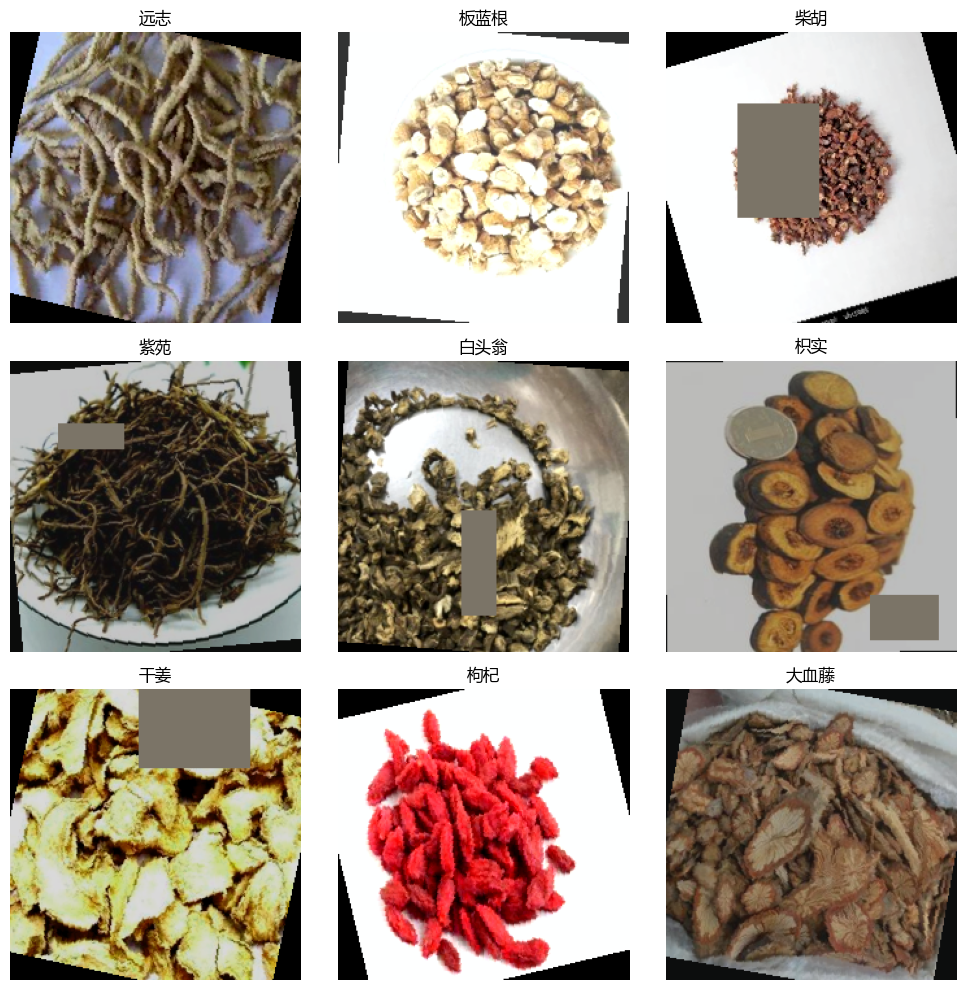

In [11]:
# Preview a few training images
display_images, display_labels = next(iter(train_loader))

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 10))
for i in range(min(9, len(display_images))):
    ax = plt.subplot(3, 3, i + 1)
    img = display_images[i].cpu().permute(1, 2, 0).numpy()
    img = np.clip((img * std) + mean, 0, 1)
    plt.imshow(img)
    plt.title(class_names[display_labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# Build pretrained ResNet18 model
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
# Helper functions
def set_backbone_trainable(model, trainable: bool):
    for name, param in model.named_parameters():
        if not name.startswith("fc."):
            param.requires_grad = trainable

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_labels), np.array(all_preds)

In [14]:
# Criterion
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [15]:
# Training history containers
history = {
    "epoch": [],
    "stage": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
best_model_path = MODELS_DIR / "transfer_resnet18_pytorch_best_model.pth"
patience_counter = 0

In [16]:
# Stage 1: train classifier head only
set_backbone_trainable(model, False)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

for epoch in range(STAGE1_EPOCHS):
    print(f"Stage 1 - Epoch {epoch + 1}/{STAGE1_EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch + 1)
    history["stage"].append("stage1_head_only")
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)
        patience_counter = 0
        print("Best model updated.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    print("-" * 60)

Stage 1 - Epoch 1/3


  0%|          | 0/797 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 2.6241 | Train Acc: 0.4118
Val   Loss: 1.8473 | Val   Acc: 0.6488
Learning Rate: 0.000500
Best model updated.
------------------------------------------------------------
Stage 1 - Epoch 2/3


  0%|          | 0/797 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 2.0680 | Train Acc: 0.5725
Val   Loss: 1.7047 | Val   Acc: 0.7049
Learning Rate: 0.000500
Best model updated.
------------------------------------------------------------
Stage 1 - Epoch 3/3


  0%|          | 0/797 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 2.0050 | Train Acc: 0.5885
Val   Loss: 1.6540 | Val   Acc: 0.7263
Learning Rate: 0.000500
Best model updated.
------------------------------------------------------------


In [17]:
# Stage 2: fine-tune all layers
set_backbone_trainable(model, True)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=STAGE2_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

for epoch in range(STAGE2_EPOCHS):
    print(f"Stage 2 - Epoch {epoch + 1}/{STAGE2_EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(STAGE1_EPOCHS + epoch + 1)
    history["stage"].append("stage2_finetune_all")
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)
        patience_counter = 0
        print("Best model updated.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    print("-" * 60)

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best validation accuracy:", best_val_acc)
print("Best model saved to:", best_model_path)

Stage 2 - Epoch 1/35


  0%|          | 0/797 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 1.5213 | Train Acc: 0.7695
Val   Loss: 1.1660 | Val   Acc: 0.9030
Learning Rate: 0.000030
Best model updated.
------------------------------------------------------------
Stage 2 - Epoch 2/35


  0%|          | 0/797 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 0.7567 | Train Acc: 0.9950
Val   Loss: 0.7538 | Val   Acc: 0.9873
Learning Rate: 0.000030
No improvement. Patience: 5/8
------------------------------------------------------------
Stage 2 - Epoch 35/35


  0%|          | 0/797 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Train Loss: 0.7538 | Train Acc: 0.9956
Val   Loss: 0.7515 | Val   Acc: 0.9884
Learning Rate: 0.000015
No improvement. Patience: 6/8
------------------------------------------------------------
Best validation accuracy: 0.9907581453634086
Best model saved to: I:\DeepLearning\ChineseHerb_Identify\models\transfer_learning\transfer_resnet18_pytorch_best_model.pth


In [18]:
# Save training history
history_df = pd.DataFrame(history)
history_path = REPORTS_DIR / "transfer_resnet18_pytorch_training_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
display(history_df.head())

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_training_history.csv


,epoch,stage,train_loss,train_acc,val_loss,val_acc,lr
0,1,stage1_head_only,2.624105,0.411842,1.847269,0.648810,0.00050
1,2,stage1_head_only,2.068049,0.572502,1.704652,0.704887,0.00050
2,3,stage1_head_only,2.005031,0.588511,1.654019,0.726347,0.00050
3,4,stage2_finetune_all,1.521297,0.769536,1.166027,0.903039,0.00003
4,5,stage2_finetune_all,1.259539,0.863354,1.044904,0.928415,0.00003


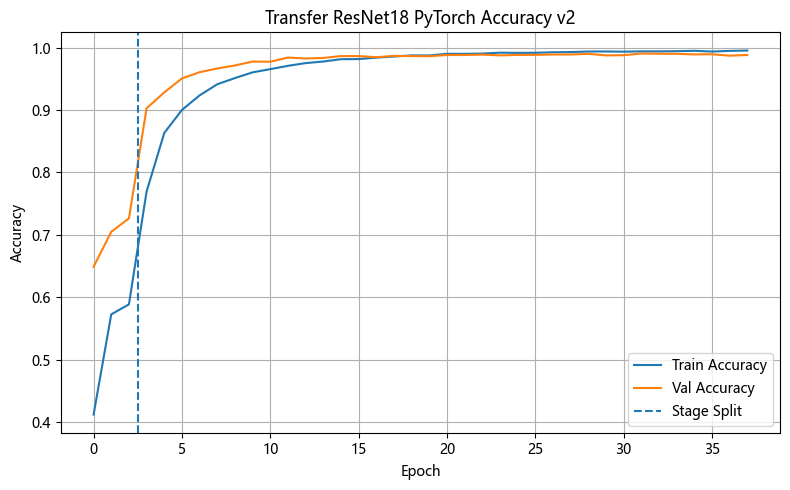

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\transfer_resnet18_pytorch_accuracy_curve.png


In [19]:
# Plot accuracy with stage split
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.axvline(x=STAGE1_EPOCHS - 0.5, linestyle="--", linewidth=1.5, label="Stage Split")
plt.title("Transfer ResNet18 PyTorch Accuracy v2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_curve_path = FIGURES_DIR / "transfer_resnet18_pytorch_accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", accuracy_curve_path)

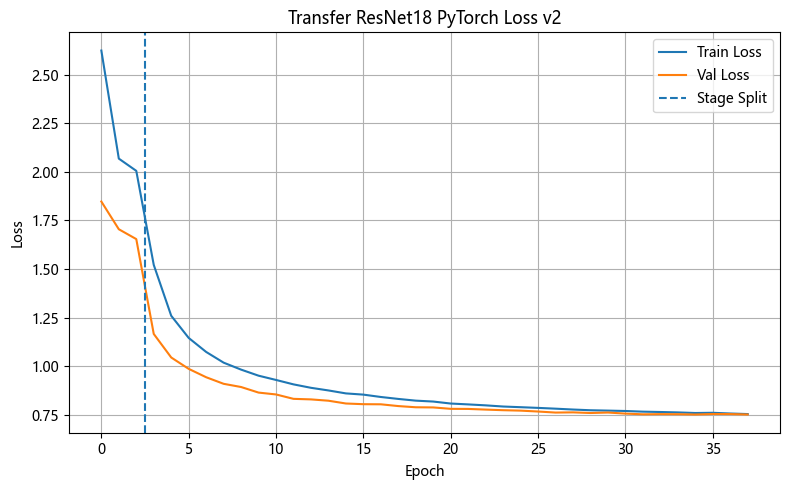

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\transfer_resnet18_pytorch_loss_curve.png


In [20]:
# Plot loss with stage split
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.axvline(x=STAGE1_EPOCHS - 0.5, linestyle="--", linewidth=1.5, label="Stage Split")
plt.title("Transfer ResNet18 PyTorch Loss v2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_curve_path = FIGURES_DIR / "transfer_resnet18_pytorch_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", loss_curve_path)

In [21]:
# Load best weights before testing
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
# Internal test evaluation
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Transfer ResNet18 v2 Test Loss: {test_loss:.4f}")
print(f"Transfer ResNet18 v2 Test Accuracy: {test_acc:.4f}")

  0%|          | 0/98 [00:00<?, ?it/s]

Transfer ResNet18 v2 Test Loss: 0.7489
Transfer ResNet18 v2 Test Accuracy: 0.9920


In [23]:
# Internal test classification report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_path = REPORTS_DIR / "transfer_resnet18_pytorch_classification_report.csv"
report_df.to_csv(report_path, encoding="utf-8-sig")

print("Saved:", report_path)
display(report_df.head(10))

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_classification_report.csv


,precision,recall,f1-score,support
乌梅,1.000000,0.991803,0.995885,122.0
侧柏叶,0.982456,1.000000,0.991150,112.0
北沙参块,0.991870,1.000000,0.995918,122.0
北沙参条,1.000000,0.990909,0.995434,110.0
半夏,1.000000,0.991379,0.995671,116.0
地龙,0.984962,1.000000,0.992424,131.0
夏枯草,1.000000,0.981818,0.990826,110.0
大血藤,1.000000,1.000000,1.000000,132.0
小茴香,0.992366,1.000000,0.996169,130.0
巴戟天,0.985816,1.000000,0.992857,139.0


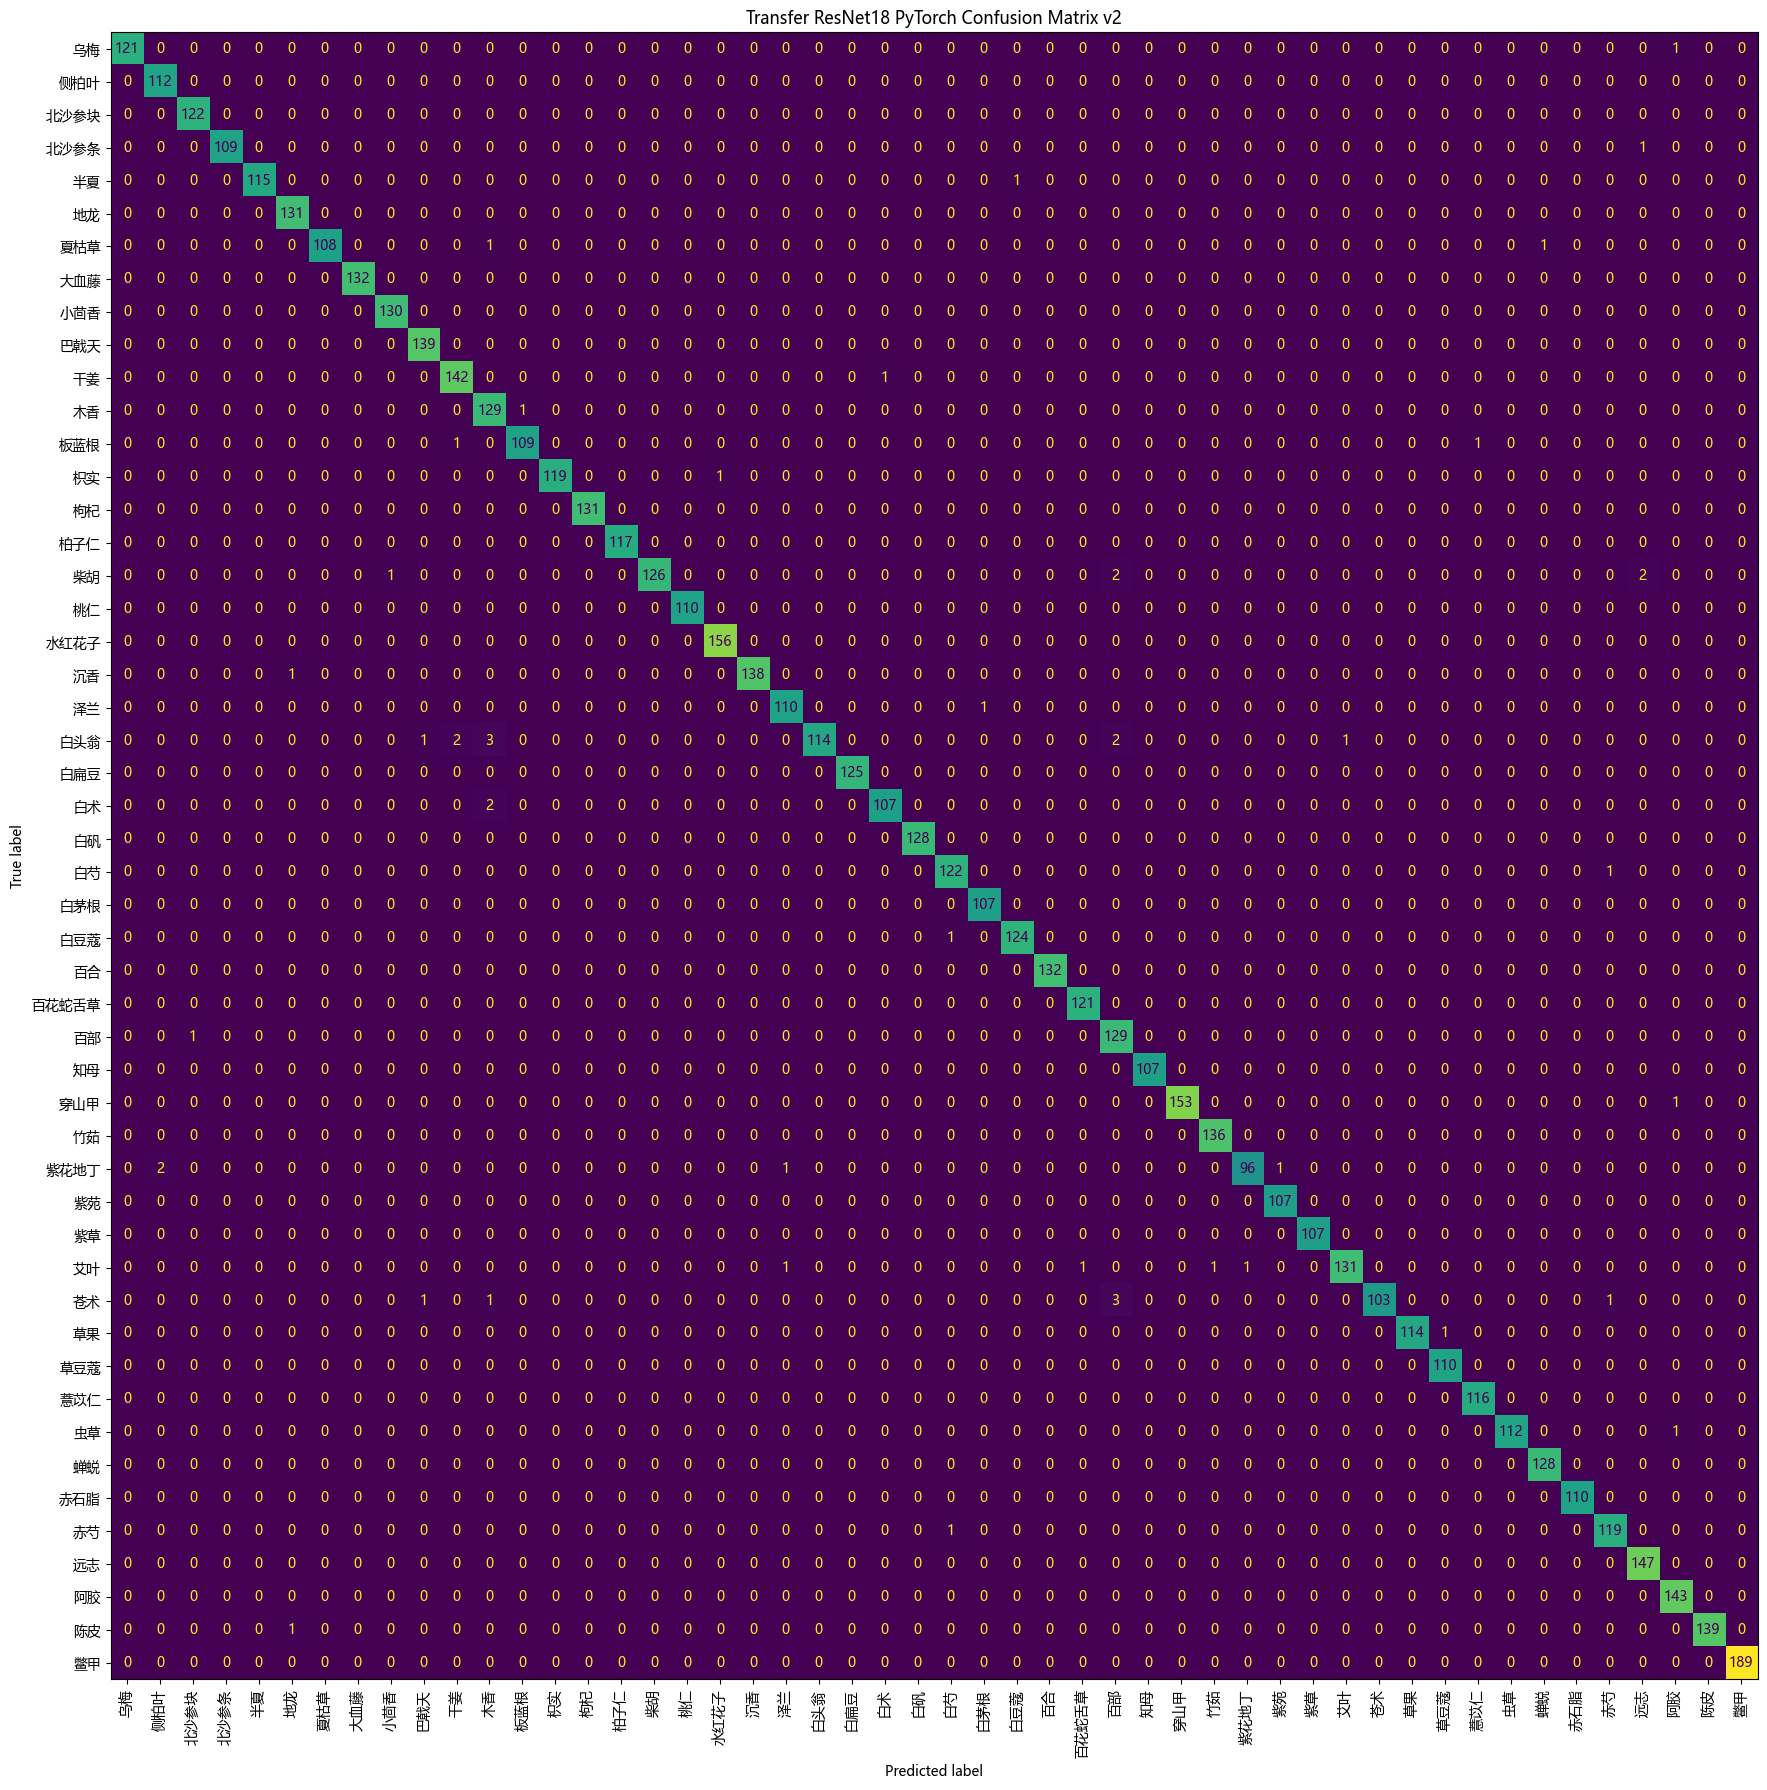

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\transfer_resnet18_pytorch_confusion_matrix.png


In [24]:
# Internal test confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 18))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Transfer ResNet18 PyTorch Confusion Matrix v2")
plt.tight_layout()

cm_path = FIGURES_DIR / "transfer_resnet18_pytorch_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

In [25]:
# External evaluation setup
external_class_names = external_test_dataset.classes
external_class_to_idx = external_test_dataset.class_to_idx
global_class_to_idx = train_dataset.class_to_idx

external_to_global_idx = {
    external_idx: global_class_to_idx[class_name]
    for class_name, external_idx in external_class_to_idx.items()
}

overlap_global_label_ids = [global_class_to_idx[class_name] for class_name in external_class_names]

print("External class names:", external_class_names)
print("External to global mapping:", external_to_global_idx)
print("Overlap global label IDs:", overlap_global_label_ids)

External class names: ['夏枯草', '巴戟天', '枸杞', '桃仁', '白头翁', '白扁豆', '白术', '白芍', '白茅根', '百合', '紫苑', '草果', '薏苡仁', '蝉蜕', '陈皮']
External to global mapping: {0: 6, 1: 9, 2: 14, 3: 17, 4: 21, 5: 22, 6: 23, 7: 25, 8: 26, 9: 28, 10: 35, 11: 39, 12: 41, 13: 43, 14: 48}
Overlap global label IDs: [6, 9, 14, 17, 21, 22, 23, 25, 26, 28, 35, 39, 41, 43, 48]


In [26]:
# External test evaluation (fixed label mapping)
external_loss, _, external_y_true_local, external_y_pred = evaluate(
    model, external_test_loader, criterion, device
)

external_y_true = np.array([
    external_to_global_idx[y] for y in external_y_true_local
])

external_acc = (external_y_true == external_y_pred).mean()

print(f"Transfer ResNet18 v2 External Loss: {external_loss:.4f}")
print(f"Transfer ResNet18 v2 External Accuracy: {external_acc:.4f}")

  0%|          | 0/6 [00:00<?, ?it/s]

Transfer ResNet18 v2 External Loss: 6.2739
Transfer ResNet18 v2 External Accuracy: 0.9538


In [27]:
# External test report (fixed label mapping)
external_report_dict = classification_report(
    external_y_true,
    external_y_pred,
    labels=overlap_global_label_ids,
    target_names=external_class_names,
    output_dict=True,
    zero_division=0
)

external_report_df = pd.DataFrame(external_report_dict).transpose()
external_report_path = REPORTS_DIR / "transfer_resnet18_pytorch_external_classification_report.csv"
external_report_df.to_csv(external_report_path, encoding="utf-8-sig")

print("Saved:", external_report_path)
display(external_report_df.head(20))

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_external_classification_report.csv


,precision,recall,f1-score,support
夏枯草,1.000000,1.000000,1.000000,18.0
巴戟天,1.000000,1.000000,1.000000,19.0
枸杞,1.000000,1.000000,1.000000,19.0
桃仁,0.971429,0.971429,0.971429,35.0
白头翁,1.000000,0.909091,0.952381,22.0
白扁豆,0.958333,0.884615,0.920000,26.0
白术,1.000000,0.923077,0.960000,26.0
白芍,0.925926,1.000000,0.961538,25.0
白茅根,1.000000,1.000000,1.000000,33.0
百合,1.000000,0.857143,0.923077,21.0


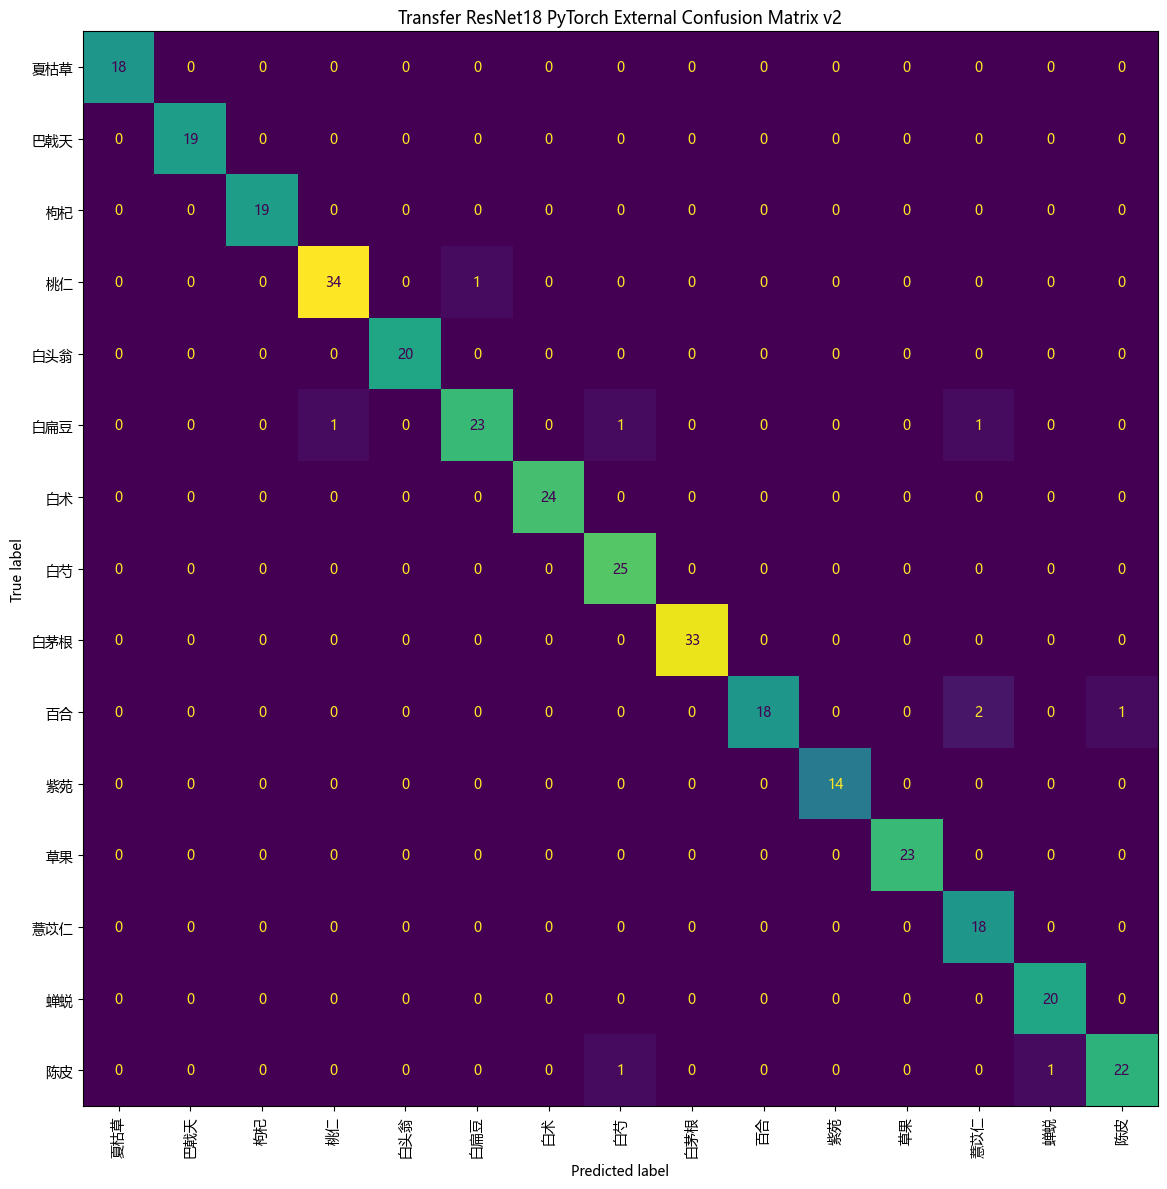

Saved: I:\DeepLearning\ChineseHerb_Identify\results\figures\transfer_resnet18_pytorch_external_confusion_matrix.png


In [28]:
# External test confusion matrix (fixed label mapping)
external_cm = confusion_matrix(
    external_y_true,
    external_y_pred,
    labels=overlap_global_label_ids
)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=external_cm,
    display_labels=external_class_names
)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Transfer ResNet18 PyTorch External Confusion Matrix v2")
plt.tight_layout()

external_cm_path = FIGURES_DIR / "transfer_resnet18_pytorch_external_confusion_matrix.png"
plt.savefig(external_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", external_cm_path)

In [29]:
# Save summary
summary = {
    "model_name": "transfer_resnet18_pytorch_v2",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "stage1_epochs": STAGE1_EPOCHS,
    "stage2_epochs": STAGE2_EPOCHS,
    "epochs_completed": len(history["train_loss"]),
    "stage1_lr": STAGE1_LR,
    "stage2_lr": STAGE2_LR,
    "weight_decay": WEIGHT_DECAY,
    "num_classes": num_classes,
    "best_val_accuracy": float(max(history["val_acc"])),
    "best_val_loss": float(min(history["val_loss"])),
    "internal_test_loss": float(test_loss),
    "internal_test_accuracy": float(test_acc),
    "external_test_loss": float(external_loss),
    "external_test_accuracy": float(external_acc),
    "device": str(device)
}

summary_path = REPORTS_DIR / "transfer_resnet18_pytorch_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=4)

print("Saved:", summary_path)
summary

Saved: I:\DeepLearning\ChineseHerb_Identify\results\reports\transfer_resnet18_pytorch_summary.json


{'model_name': 'transfer_resnet18_pytorch_v2',
 'image_size': 224,
 'batch_size': 64,
 'stage1_epochs': 3,
 'stage2_epochs': 35,
 'epochs_completed': 38,
 'stage1_lr': 0.0005,
 'stage2_lr': 3e-05,
 'weight_decay': 0.0005,
 'num_classes': 50,
 'best_val_accuracy': 0.9907581453634086,
 'best_val_loss': 0.7514676433756835,
 'internal_test_loss': 0.748890285773516,
 'internal_test_accuracy': 0.9919768934531451,
 'external_test_loss': 6.273947142452174,
 'external_test_accuracy': 0.953757225433526,
 'device': 'cuda'}